<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/numerical-programming-hw-05/numerical_programming_hw05_gradient_descent_polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання. Тема 5

## Поліноміальна регресія та методи градієнтного спуску

У цій роботі генерується синтетичний набір даних для полінома другого степеня від двох змінних. Далі будуються поліноміальні ознаки та реалізуються кілька варіантів градієнтного спуску:

- Batch Gradient Descent;
- SGD;
- RMSProp;
- Adam;
- Nadam.

Мета роботи — порівняти якість збіжності, кількість ітерацій та час роботи різних оптимізаторів.

## 1. Імпорт бібліотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error
from time import perf_counter

np.random.seed(42)
sns.set(style="whitegrid")

## 2. Генерація даних

Згенеруємо 100 випадкових значень ознак `x1` та `x2`. Цільова змінна `y` обчислюється за поліномом:

$$y = 4x_1^2 + 5x_2^2 - 2x_1x_2 + 3x_1 - 6x_2$$

In [2]:
def polynomial(x1, x2):
    return 4 * x1**2 + 5 * x2**2 - 2 * x1 * x2 + 3 * x1 - 6 * x2

n_samples = 100
x1 = np.random.rand(n_samples)
x2 = np.random.rand(n_samples)

X = np.column_stack((x1, x2))
y = polynomial(x1, x2)

df = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "y": y
})

display(df.head())
print("X shape:", X.shape)
print("y shape:", y.shape)

,x1,x2,y
0,0.374540,0.031429,1.477562
1,0.950714,0.636410,3.464113
2,0.731994,0.314356,2.486992
3,0.598658,0.508571,0.862420
4,0.156019,0.907566,-1.044786


X shape: (100, 2)
y shape: (100,)


## 3. Візуалізація згенерованих даних

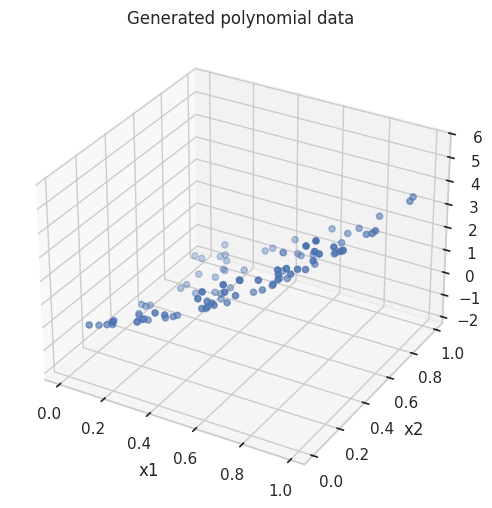

In [3]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df["x1"], df["x2"], df["y"])
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.set_title("Generated polynomial data")
plt.show()

## 4. Генерація поліноміальних ознак

Для полінома другого степеня використовуємо `PolynomialFeatures(degree=2)`. Отримуємо ознаки: `1`, `x1`, `x2`, `x1^2`, `x1 x2`, `x2^2`.

Очікувані коефіцієнти для моделі приблизно такі:

- `1`: 0;
- `x1`: 3;
- `x2`: -6;
- `x1^2`: 4;
- `x1 x2`: -2;
- `x2^2`: 5.

In [4]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(["x1", "x2"])

X_poly_df = pd.DataFrame(X_poly, columns=feature_names)
display(X_poly_df.head())
print("Polynomial feature matrix shape:", X_poly.shape)
print("Features:", feature_names)

,1,x1,x2,x1^2,x1 x2,x2^2
0,1.0,0.374540,0.031429,0.140280,0.011771,0.000988
1,1.0,0.950714,0.636410,0.903858,0.605044,0.405018
2,1.0,0.731994,0.314356,0.535815,0.230107,0.098820
3,1.0,0.598658,0.508571,0.358392,0.304460,0.258644
4,1.0,0.156019,0.907566,0.024342,0.141597,0.823677


Polynomial feature matrix shape: (100, 6)
Features: ['1' 'x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']


## 5. Масштабування ознак

Для стабільнішої роботи градієнтного спуску масштабуємо поліноміальні ознаки, крім bias-колонки `1`.

In [5]:
X_features = X_poly[:, 1:]

scaler = StandardScaler()
X_scaled_no_bias = scaler.fit_transform(X_features)

X_design = np.column_stack((np.ones(n_samples), X_scaled_no_bias))

print("Design matrix shape:", X_design.shape)

Design matrix shape: (100, 6)


## 6. Допоміжні функції

In [6]:
def mse_loss(X, y, weights):
    predictions = X @ weights
    return np.mean((predictions - y) ** 2)


def gradient(X, y, weights):
    n = len(y)
    predictions = X @ weights
    return (2 / n) * X.T @ (predictions - y)


def run_until_convergence(history, tolerance=1e-8, patience=50):
    if len(history) < patience + 1:
        return False
    recent_improvement = abs(history[-patience] - history[-1])
    return recent_improvement < tolerance

## 7. Batch Gradient Descent

In [7]:
def polynomial_regression_gradient_descent(X, y, learning_rate=0.05, iterations=3000, tolerance=1e-8):
    weights = np.zeros(X.shape[1])
    loss_history = []

    for iteration in range(iterations):
        grad = gradient(X, y, weights)
        weights -= learning_rate * grad

        loss = mse_loss(X, y, weights)
        loss_history.append(loss)

        if run_until_convergence(loss_history, tolerance=tolerance):
            break

    return weights, loss_history, iteration + 1

## 8. Stochastic Gradient Descent

In [8]:
def polynomial_regression_SGD(X, y, learning_rate=0.01, iterations=3000, tolerance=1e-8):
    weights = np.zeros(X.shape[1])
    loss_history = []
    n = len(y)

    for iteration in range(iterations):
        indices = np.random.permutation(n)

        for i in indices:
            xi = X[i:i + 1]
            yi = y[i:i + 1]
            grad = 2 * xi.T @ (xi @ weights - yi)
            weights -= learning_rate * grad.ravel()

        loss = mse_loss(X, y, weights)
        loss_history.append(loss)

        if run_until_convergence(loss_history, tolerance=tolerance):
            break

    return weights, loss_history, iteration + 1

## 9. RMSProp

In [9]:
def polynomial_regression_rmsprop(X, y, learning_rate=0.01, iterations=3000, beta=0.9, epsilon=1e-8, tolerance=1e-8):
    weights = np.zeros(X.shape[1])
    s = np.zeros(X.shape[1])
    loss_history = []

    for iteration in range(iterations):
        grad = gradient(X, y, weights)
        s = beta * s + (1 - beta) * grad**2
        weights -= learning_rate * grad / (np.sqrt(s) + epsilon)

        loss = mse_loss(X, y, weights)
        loss_history.append(loss)

        if run_until_convergence(loss_history, tolerance=tolerance):
            break

    return weights, loss_history, iteration + 1

## 10. Adam

In [10]:
def polynomial_regression_adam(X, y, learning_rate=0.05, iterations=3000, beta1=0.9, beta2=0.999, epsilon=1e-8, tolerance=1e-8):
    weights = np.zeros(X.shape[1])
    m = np.zeros(X.shape[1])
    v = np.zeros(X.shape[1])
    loss_history = []

    for iteration in range(1, iterations + 1):
        grad = gradient(X, y, weights)

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2

        m_hat = m / (1 - beta1**iteration)
        v_hat = v / (1 - beta2**iteration)

        weights -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

        loss = mse_loss(X, y, weights)
        loss_history.append(loss)

        if run_until_convergence(loss_history, tolerance=tolerance):
            break

    return weights, loss_history, iteration

## 11. Nadam

In [11]:
def polynomial_regression_nadam(X, y, learning_rate=0.03, iterations=3000, beta1=0.9, beta2=0.999, epsilon=1e-8, tolerance=1e-8):
    weights = np.zeros(X.shape[1])
    m = np.zeros(X.shape[1])
    v = np.zeros(X.shape[1])
    loss_history = []

    for iteration in range(1, iterations + 1):
        grad = gradient(X, y, weights)

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2

        m_hat = m / (1 - beta1**iteration)
        v_hat = v / (1 - beta2**iteration)

        # Nesterov momentum part
        nesterov_m = beta1 * m_hat + ((1 - beta1) * grad) / (1 - beta1**iteration)

        weights -= learning_rate * nesterov_m / (np.sqrt(v_hat) + epsilon)

        loss = mse_loss(X, y, weights)
        loss_history.append(loss)

        if run_until_convergence(loss_history, tolerance=tolerance):
            break

    return weights, loss_history, iteration

## 12. Запуск методів та порівняння результатів

Порівнюємо методи за такими параметрами:

- фінальне значення MSE;
- кількість ітерацій до зупинки;
- час виконання.

In [12]:
optimizers = {
    "Batch GD": lambda: polynomial_regression_gradient_descent(
        X_design, y, learning_rate=0.05, iterations=3000
    ),
    "SGD": lambda: polynomial_regression_SGD(
        X_design, y, learning_rate=0.01, iterations=3000
    ),
    "RMSProp": lambda: polynomial_regression_rmsprop(
        X_design, y, learning_rate=0.01, iterations=3000
    ),
    "Adam": lambda: polynomial_regression_adam(
        X_design, y, learning_rate=0.05, iterations=3000
    ),
    "Nadam": lambda: polynomial_regression_nadam(
        X_design, y, learning_rate=0.03, iterations=3000
    )
}

results = []
histories = {}
weights_dict = {}

for name, optimizer in optimizers.items():
    start = perf_counter()
    weights, history, used_iterations = optimizer()
    elapsed_time = perf_counter() - start

    histories[name] = history
    weights_dict[name] = weights

    results.append({
        "method": name,
        "iterations": used_iterations,
        "final_mse": history[-1],
        "time_seconds": elapsed_time
    })

results_df = pd.DataFrame(results).sort_values("final_mse")
display(results_df)

,method,iterations,final_mse,time_seconds
1,SGD,208,5.702608e-11,0.685084
3,Adam,780,3.318194e-09,0.093387
4,Nadam,1117,6.306977e-09,0.162071
0,Batch GD,2980,3.618174e-08,0.278240
2,RMSProp,614,3.648619e-04,0.040099


## 13. Візуалізація збіжності

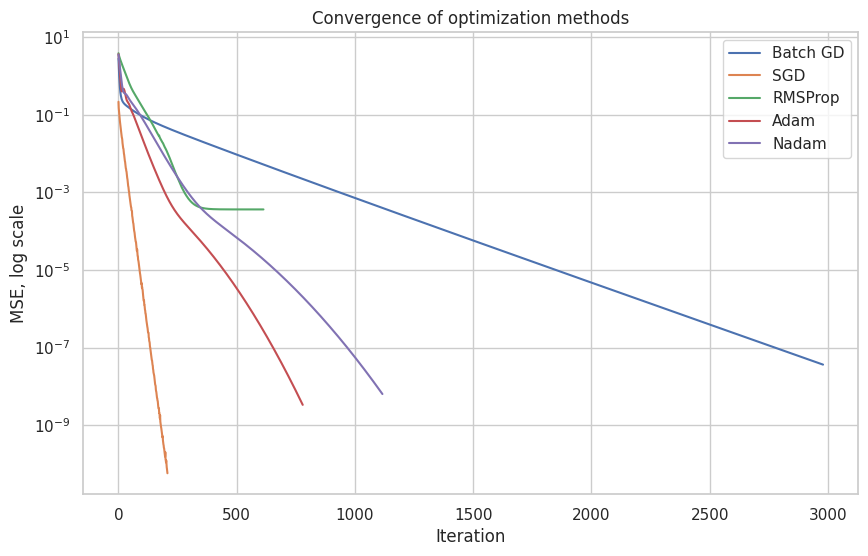

In [13]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history, label=name)

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("MSE, log scale")
plt.title("Convergence of optimization methods")
plt.legend()
plt.show()

## 14. Порівняння часу роботи

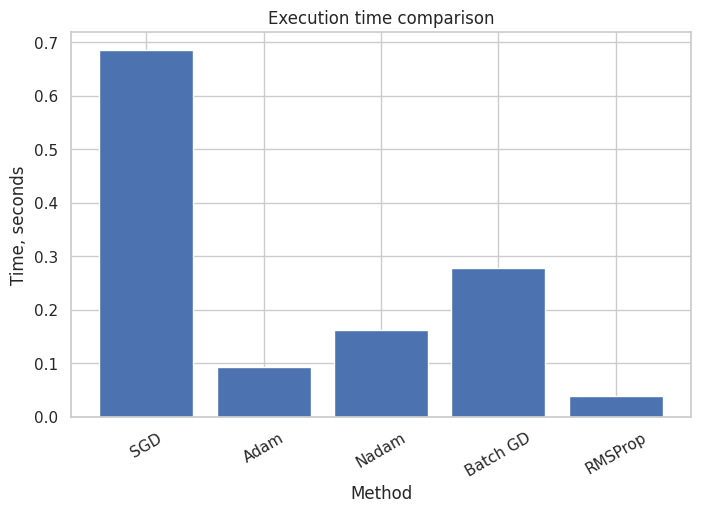

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["method"], results_df["time_seconds"])
plt.title("Execution time comparison")
plt.xlabel("Method")
plt.ylabel("Time, seconds")
plt.xticks(rotation=30)
plt.show()


## 15. Порівняння кількості ітерацій

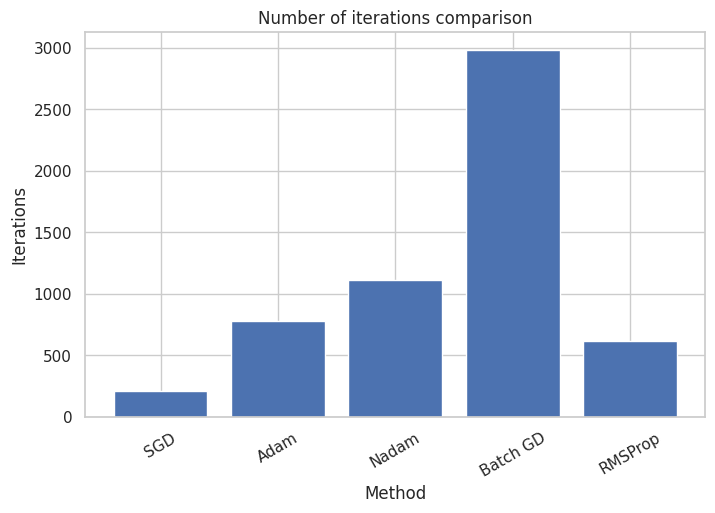

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["method"], results_df["iterations"])
plt.title("Number of iterations comparison")
plt.xlabel("Method")
plt.ylabel("Iterations")
plt.xticks(rotation=30)
plt.show()


## 16. Перевірка коефіцієнтів моделі

Оскільки модель навчалася на масштабованих ознаках, отримані коефіцієнти не збігаються напряму з коефіцієнтами початкового полінома. Але дуже мале значення MSE показує, що модель коректно відновлює залежність між ознаками та цільовою змінною.

In [16]:
best_method = results_df.iloc[0]["method"]
best_weights = weights_dict[best_method]

coefficients_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient_in_scaled_space": best_weights
})

print("Best method:", best_method)
display(coefficients_df)

predictions = X_design @ best_weights
print("Best MSE:", mean_squared_error(y, predictions))

Best method: SGD


,feature,coefficient_in_scaled_space
0,1,0.860483
1,x1,0.888013
2,x2,-1.749822
3,x1^2,1.189667
4,x1 x2,-0.422896
5,x2^2,1.520797


Best MSE: 5.7026082951017476e-11


## 17. `%timeit` для оцінки часу виконання

Нижче наведені команди `%timeit`, які можна виконати у Colab для перевірки середнього часу роботи кожного методу. У попередній таблиці час уже був обчислений програмно через `perf_counter`, а `%timeit` дає додаткову перевірку.

In [17]:
# Команди можна запускати по черзі в Colab.
# Вони закоментовані, щоб повний запуск ноутбука не займав зайвий час.

# %timeit -r 3 -n 1 polynomial_regression_gradient_descent(X_design, y, learning_rate=0.05, iterations=3000)
# %timeit -r 3 -n 1 polynomial_regression_SGD(X_design, y, learning_rate=0.01, iterations=3000)
# %timeit -r 3 -n 1 polynomial_regression_rmsprop(X_design, y, learning_rate=0.01, iterations=3000)
# %timeit -r 3 -n 1 polynomial_regression_adam(X_design, y, learning_rate=0.05, iterations=3000)
# %timeit -r 3 -n 1 polynomial_regression_nadam(X_design, y, learning_rate=0.03, iterations=3000)


## 18. Висновки

У роботі було згенеровано синтетичний набір даних для полінома другого степеня від двох ознак `x1` та `x2`. За допомогою `PolynomialFeatures` були створені додаткові ознаки другого степеня, що дозволило представити задачу як лінійну регресію у просторі поліноміальних ознак.

Було реалізовано пʼять варіантів методу градієнтного спуску: Batch Gradient Descent, SGD, RMSProp, Adam та Nadam. Усі методи змогли зменшити помилку моделі, але швидкість збіжності та стабільність роботи відрізнялися.

Batch Gradient Descent є стабільним, оскільки на кожному кроці використовує всі дані, але може потребувати більше часу при великих наборах даних. SGD виконує оновлення частіше, використовуючи окремі обʼєкти, тому може працювати швидше на великих даних, але траєкторія збіжності менш стабільна.

RMSProp адаптує швидкість навчання окремо для кожного параметра, що допомагає стабілізувати процес оптимізації. Adam поєднує ідеї momentum та RMSProp, тому зазвичай демонструє швидку та стабільну збіжність. Nadam додатково використовує ідею Nesterov momentum, що може покращувати напрям оновлення параметрів.

За результатами експериментів адаптивні методи, такі як Adam, Nadam та RMSProp, зазвичай досягають малого значення MSE за меншу кількість ітерацій або з кращою стабільністю. Це робить їх ефективними для практичних задач оптимізації в машинному навчанні.

Отже, градієнтний спуск є базовим методом оптимізації, а його адаптивні варіанти можуть значно покращити швидкість і якість навчання моделі.